<a href="https://colab.research.google.com/github/nakkue/deeplearning/blob/main/2%EC%A3%BC%EC%B0%A8_%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#[라이브러리 및 환경설정]
!pip install PyWavelets -q

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, iirnotch, filtfilt, welch
import pywt
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torchvision.models import densenet161

# 기본 설정
FS, WIN, HOP = 1000, 300, 150
SCALES = np.arange(1, 33)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

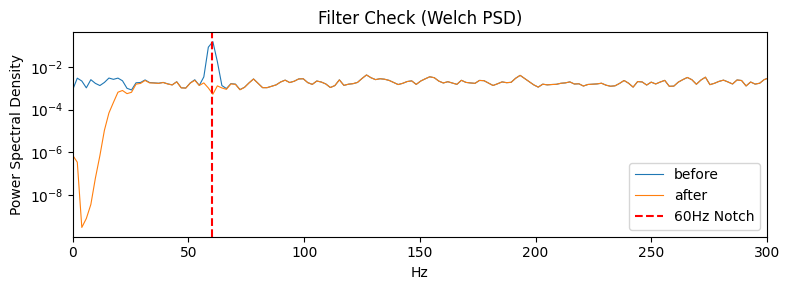

In [4]:
#[필터 적용 및 검증]
def preprocess(x, fs=FS):
    bn, an = iirnotch(60, 30, fs)
    x = filtfilt(bn, an, x, axis=0)
    b, a = butter(4, [20/(fs/2), 499/(fs/2)], btype='band')
    return filtfilt(b, a, x, axis=0)

np.random.seed(42)
x_dummy = np.random.randn(3000, 2) + np.sin(2 * np.pi * 60 * np.linspace(0, 3, 3000))[:, None]
xf_dummy = preprocess(x_dummy)

# ① 필터 검증 그림 시각화 및 저장
f0, P0 = welch(x_dummy[:, 0], fs=FS, nperseg=512)
f1, P1 = welch(xf_dummy[:, 0], fs=FS, nperseg=512)

plt.figure(figsize=(8, 3))
plt.semilogy(f0, P0, label='before', lw=0.8)
plt.semilogy(f1, P1, label='after', lw=0.8)
plt.axvline(60, color='r', ls='--', label='60Hz Notch')
plt.xlim(0, 300)
plt.xlabel('Hz')
plt.ylabel('Power Spectral Density')
plt.title('Filter Check (Welch PSD)')
plt.legend()
plt.tight_layout()
plt.savefig('filter_check.png', dpi=120)
plt.show()

In [6]:
#[윈도우 분할 및 정규화]
def make_windows(x, win=WIN, hop=HOP):
    n = (len(x) - win) // hop + 1
    return np.stack([x[i*hop : i*hop+win] for i in range(n)])

def minmax(w, eps=1e-8):
    mn = w.min(axis=(1,2), keepdims=True)
    mx = w.max(axis=(1,2), keepdims=True)
    return (w - mn) / (mx - mn + eps)

wn = minmax(make_windows(xf_dummy))

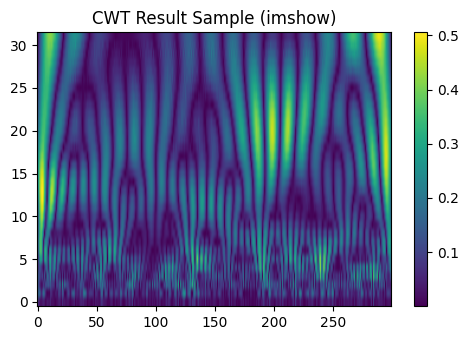

In [7]:
#[CWT예시그림]
def to_cwt(one_window, wavelet='morl'):
    maps = []
    for ch in range(one_window.shape[1]):
        coef, _ = pywt.cwt(one_window[:, ch], SCALES, wavelet)
        maps.append(np.abs(coef))
    maps.append((maps[0] + maps[1]) / 2) # 3번째 채널: 평균
    return np.stack(maps).astype(np.float32)

t = to_cwt(wn[0])

# ② CWT 예시 그림 시각화 및 저장
plt.figure(figsize=(5, 3.5))
plt.imshow(t[0], aspect='auto', origin='lower')
plt.title("CWT Result Sample (imshow)")
plt.colorbar()
plt.tight_layout()
plt.savefig('cwt_example.png', dpi=120)
plt.show()

In [9]:
# 더미 데이터 20개 생성 (오류 방지용 균등 클래스 배치)
np.random.seed(42)
dummy_files = [np.random.randn(3000, 2) + np.sin(2 * np.pi * 60 * np.linspace(0, 3, 3000))[:, None] for _ in range(20)]
dummy_labels = np.repeat(np.arange(5), 4)

# ========================================================
# 시행 단위 분할 (데이터 누수 방지 핵심 코드)
# ========================================================
tr_files, te_files, tr_labels, te_labels = train_test_split(
    dummy_files, dummy_labels, test_size=0.25, stratify=dummy_labels, random_state=42
)

def build_dataset(flist, llist):
    X, y = [], []
    for sig, lbl in zip(flist, llist):
        sig_p = preprocess(sig)
        for w in minmax(make_windows(sig_p)):
            X.append(to_cwt(w))
            y.append(lbl)
    return np.stack(X), np.array(y)

X_train, y_train = build_dataset(tr_files, tr_labels)
X_test, y_test = build_dataset(te_files, te_labels)

train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train, dtype=torch.long))
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)

# ========================================================
# 데이터셋 요약 (학습/테스트 샘플 수 및 클래스별 분포 표)
# ========================================================
classes, tr_counts = np.unique(y_train, return_counts=True)
_, te_counts = np.unique(y_test, return_counts=True)

summary_df = pd.DataFrame({
    'Class': classes,
    'Train Samples': tr_counts,
    'Test Samples': te_counts
})
summary_df.loc['Total'] = ['Total', len(y_train), len(y_test)]

print("=== ③ 데이터셋 요약 표 ===")
display(summary_df)

=== ③ 데이터셋 요약 표 ===


,Class,Train Samples,Test Samples
0,0,57,19
1,1,57,19
2,2,57,19
3,3,57,19
4,4,57,19
Total,Total,285,95


설정 근거
윈도우 크기 (300ms) 설정 이유
너무 길게 잡으면 동작이 변하는 순간의 주파수 특징이 뭉개지고, 너무 짧으면 주파수 성분을 제대로 보기 힘들어서 300ms로 설정했습니다. 연산량도 적당하면서 신호의 국소적인 변화를 잡기에 제일 적절한 크기라고 생각했습니다.

스케일 개수 (32개) 설정 이유
주요 주파수 대역의 변화를 부족함 없이 해상도 높게 나타내기 위해 1부터 32까지 스케일을 지정했습니다. 32개 채널/높이 수준으로 맞춰주어야 CWT 변환 후 이미지 형태가 DenseNet161 모델에 들어가기에 특징 표현력과 메모리 효율 균형이 제일 잘 맞았습니다.